In [1]:
import sys
import os
from pathlib import Path

# Tambahkan root project ke path agar bisa import modul footballanalytix
current_dir = Path(os.getcwd())
project_root = current_dir.parent
sys.path.append(str(project_root))

import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Import modul internal
from footballanalytix.config import FIELD_MODEL_PATH, DEFAULT_VIDEO_PATH
from footballanalytix.field import SoccerPitchConfiguration, detect_field_keypoints

print(f"Project Root: {project_root}")
print(f"Model Path: {FIELD_MODEL_PATH}")

Project Root: d:\Project\FootballAnalytix
Model Path: D:\Project\FootballAnalytix\Models\Fields.pt


Model loaded successfully.


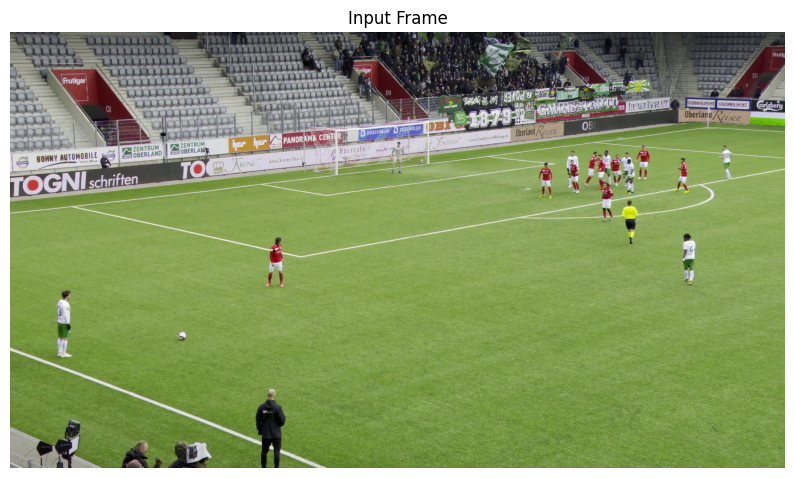

In [2]:
# Load Model
try:
    field_model = YOLO(FIELD_MODEL_PATH)
    print("Model loaded successfully.")
except Exception as e:
    print(f"Error loading model: {e}")
    print("Pastikan file 'Models/Fields.pt' ada.")

video_path = DEFAULT_VIDEO_PATH

cap = cv2.VideoCapture(str(video_path))
if not cap.isOpened():
    print(f"Warning: Video not found at {video_path}. Using dummy black image for code structure demonstration.")
    frame = np.zeros((720, 1280, 3), dtype=np.uint8)
else:
    # Ambil frame ke-100 agar lapangan terlihat jelas
    cap.set(cv2.CAP_PROP_POS_FRAMES, 100)
    ret, frame = cap.read()
    if not ret:
        print("Failed to read frame.")
        frame = np.zeros((720, 1280, 3), dtype=np.uint8)
    cap.release()

# Tampilkan Frame
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.title("Input Frame")
plt.axis('off')
plt.show()

Detected 9 keypoints.
Average Confidence: 0.9536


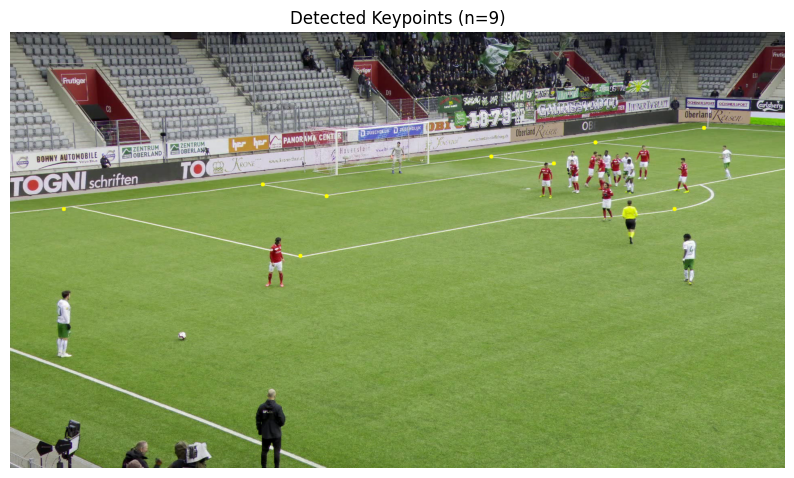


Sample Correspondences:
Frame (x, y)         | Pitch (x', y')      
---------------------------------------------
( 1719.49,   237.90) | (    0.00,     0.00)
( 1450.62,   273.78) | (    0.00,  1430.00)
(  133.05,   438.45) | (    0.00,  5570.00)
(  719.36,   554.59) | ( 1886.00,  5570.00)
( 1192.18,   308.66) | (    0.00,  2557.50)


In [3]:
# Konfigurasi Lapangan
config = SoccerPitchConfiguration()

# Deteksi Keypoints
# Confidence threshold kita set agak tinggi biar dapet point yang bagus
frame_points, pitch_points, avg_conf = detect_field_keypoints(frame, field_model, config, confidence=0.5)

print(f"Detected {len(frame_points)} keypoints.")
print(f"Average Confidence: {avg_conf:.4f}")

# Visualisasi Titik yang Terdeteksi
frame_vis = frame.copy()
for pt in frame_points:
    cv2.circle(frame_vis, (int(pt[0]), int(pt[1])), 5, (0, 255, 255), -1)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(frame_vis, cv2.COLOR_BGR2RGB))
plt.title(f"Detected Keypoints (n={len(frame_points)})")
plt.axis('off')
plt.show()

# Tampilkan beberapa sampel data
print("\nSample Correspondences:")
print("{:<20} | {:<20}".format("Frame (x, y)", "Pitch (x', y')"))
print("-" * 45)
for i in range(min(5, len(frame_points))):
    fx, fy = frame_points[i]
    px, py = pitch_points[i]
    print(f"({fx:8.2f}, {fy:8.2f}) | ({px:8.2f}, {py:8.2f})")

In [4]:
def calculate_homography_dlt(src_points, dst_points):
    """
    Menghitung Homography Matrix menggunakan DLT dan SVD.
    
    Args:
        src_points: Nx2 numpy array (titik di frame)
        dst_points: Nx2 numpy array (titik di pitch)
        
    Returns:
        H: 3x3 Homography matrix
    """
    if len(src_points) < 4:
        raise ValueError("Butuh minimal 4 titik untuk menghitung Homography.")

    # --- Langkah 1: Normalisasi Data (PENTING untuk stabilitas numerik DLT) ---
    # Kita geser centroid ke (0,0) dan scale agar rata-rata jarak ke pusat adalah sqrt(2)
    def normalize(points):
        centroid = np.mean(points, axis=0)
        shifted = points - centroid
        avg_dist = np.mean(np.sqrt(np.sum(shifted**2, axis=1)))
        scale = np.sqrt(2) / avg_dist
        
        T = np.array([
            [scale, 0, -scale * centroid[0]],
            [0, scale, -scale * centroid[1]],
            [0, 0, 1]
        ])
        
        # Transform points: tambahkan kolom 1 untuk koordinat homogen
        pts_h = np.column_stack((points, np.ones(len(points))))
        pts_norm = (T @ pts_h.T).T
        return pts_norm[:, :2], T

    src_norm, T_src = normalize(src_points)
    dst_norm, T_dst = normalize(dst_points)

    # --- Langkah 2: Membangun Matriks A ---
    num_points = len(src_points)
    A = np.zeros((2 * num_points, 9))

    for i in range(num_points):
        x, y = src_norm[i]
        xp, yp = dst_norm[i]
        
        # Baris 1 (untuk x')
        A[2*i]     = [-x, -y, -1, 0, 0, 0, x*xp, y*xp, xp]
        # Baris 2 (untuk y')
        A[2*i + 1] = [0, 0, 0, -x, -y, -1, x*yp, y*yp, yp]

    # --- Langkah 3: SVD (Singular Value Decomposition) ---
    # A = U * Sigma * Vt
    # Solusi h adalah baris terakhir dari Vt (atau kolom terakhir V)
    U, S, Vt = np.linalg.svd(A)
    
    # Ambil baris terakhir Vt
    h = Vt[-1]
    
    # Reshape menjadi 3x3
    H_norm = h.reshape(3, 3)

    # --- Langkah 4: Denormalisasi ---
    # H = inv(T_dst) * H_norm * T_src
    H = np.linalg.inv(T_dst) @ H_norm @ T_src
    
    # Normalisasi H agar H[2,2] = 1 (konvensi)
    H = H / H[2, 2]
    
    return H

# Jalankan perhitungan manual jika titik cukup
if len(frame_points) >= 4:
    H_manual = calculate_homography_dlt(frame_points, pitch_points)
    print("Calculated Homography Matrix (Manual DLT):")
    print(np.round(H_manual, 4))
else:
    print("Not enough points detected to calculate Homography.")
    H_manual = None

Calculated Homography Matrix (Manual DLT):
[[     8.6902      69.882      -31744]
 [    -8.0351      100.02     -9924.8]
 [          0      0.0111           1]]


In [9]:
from IPython.display import display, Markdown, Math

def to_latex(mat, precision=4):
    """Konversi numpy array ke LaTeX bmatrix string."""
    if len(mat.shape) == 1:
        mat = mat.reshape(1, -1)
    
    lines = []
    for row in mat:
        lines.append(" & ".join([f"{val:.{precision}f}" for val in row]))
    return r"\begin{bmatrix} " + " \\\\ ".join(lines) + r" \end{bmatrix}"

# Kalkulasi manual langkah demi langkah (tampilkan setiap matriks)
if len(frame_points) >= 4:
    N_DEMO = 4
    src_sample = np.array(frame_points[:N_DEMO], dtype=float)
    dst_sample = np.array(pitch_points[:N_DEMO], dtype=float)

    display(Markdown(f"### 🧪 Demonstrasi Langkah-demi-Langkah (N={N_DEMO})"))
    display(Markdown("> **Note:** Demonstrasi ini menggunakan 4 titik pertama untuk kemudahan visualisasi. "
                     "Hasil akan berbeda dengan Cell sebelumnya yang menggunakan SEMUA titik (Least Squares)."))

    def display_step(title, content=""):
        display(Markdown(f"#### {title}"))
        if content:
            display(Markdown(content))

    def display_mat(title, mat, precision=4):
        display(Markdown(f"**{title}:**"))
        display(Math(to_latex(mat, precision)))

    # 1. Sampel Korespondensi
    display_step("1. Sampel Korespondensi (Input)")
    corr_text = "| Point | Frame (x, y) | Pitch (x', y') |\n| :--- | :--- | :--- |\n"
    for i, (s, d) in enumerate(zip(src_sample, dst_sample), 1):
        corr_text += f"| {i} | `({s[0]:.2f}, {s[1]:.2f})` | `({d[0]:.2f}, {d[1]:.2f})` |\n"
    display(Markdown(corr_text))

    def normalize_verbose(points, label):
        display_step(f"2. Normalisasi {label.upper()}")
        
        # Centroid
        centroid = np.mean(points, axis=0)
        cx_sum = " + ".join([f"{p[0]:.2f}" for p in points])
        cy_sum = " + ".join([f"{p[1]:.2f}" for p in points])
        
        display(Markdown(f"**a. Hitung Centroid (rata-rata):**"))
        display(Math(rf"c_x = \frac{{{cx_sum}}}{{{len(points)}}} = {centroid[0]:.4f}"))
        display(Math(rf"c_y = \frac{{{cy_sum}}}{{{len(points)}}} = {centroid[1]:.4f}"))
        
        # Distance
        shifted = points - centroid
        dists = np.sqrt(np.sum(shifted**2, axis=1))
        avg_dist = np.mean(dists)
        scale = np.sqrt(2) / avg_dist
        
        display(Markdown(f"**b. Hitung Jarak Rata-rata & Scale Factor:**"))
        display(Markdown(f"Distances: `[{', '.join([f'{d:.4f}' for d in dists])}]`"))
        display(Math(rf"\text{{Avg Dist}} = {avg_dist:.4f}"))
        display(Math(rf"\text{{Scale}} = \frac{{\sqrt{{2}}}}{{{avg_dist:.4f}}} = {scale:.6f}"))

        # T Matrix
        T = np.array([
            [scale, 0, -scale * centroid[0]],
            [0, scale, -scale * centroid[1]],
            [0, 0, 1]
        ])
        display_mat(f"Matriks Transformasi $T_{{{label}}}$", T)

        # Apply
        pts_h = np.column_stack((points, np.ones(len(points))))
        pts_norm = (T @ pts_h.T).T
        
        display(Markdown(f"**c. Titik Ternormalisasi ($T_{{{label}}} \cdot P$):**"))
        norm_text = "| Point | Original | Normalized |\n| :--- | :--- | :--- |\n"
        for i, (p, pn) in enumerate(zip(points, pts_norm), 1):
            norm_text += f"| {i} | `({p[0]:.2f}, {p[1]:.2f})` | `({pn[0]:.4f}, {pn[1]:.4f})` |\n"
        display(Markdown(norm_text))
        
        return pts_norm[:, :2], T

    src_norm, T_src = normalize_verbose(src_sample, "src")
    dst_norm, T_dst = normalize_verbose(dst_sample, "dst")

    # 3. Matriks A
    display_step("3. Membangun Matriks A")
    display(Markdown("Persamaan DLT: $Ah = 0$. Untuk setiap titik $i$, kita buat 2 baris di $A$:"))
    display(Math(r"A_i = \begin{bmatrix} -x & -y & -1 & 0 & 0 & 0 & x x' & y x' & x' \\ 0 & 0 & 0 & -x & -y & -1 & x y' & y y' & y' \end{bmatrix}"))
    
    # Detail baris pertama
    x, y = src_norm[0]
    xp, yp = dst_norm[0]
    display(Markdown(f"**Contoh pengisian untuk Titik 1:**"))
    display(Math(rf"x={x:.4f}, y={y:.4f}, x'={xp:.4f}, y'={yp:.4f}"))
    row0 = [-x, -y, -1, 0, 0, 0, x*xp, y*xp, xp]
    row1 = [0, 0, 0, -x, -y, -1, x*yp, y*yp, yp]
    display(Math(rf"Row_0 = {to_latex(np.array(row0))}"))
    display(Math(rf"Row_1 = {to_latex(np.array(row1))}"))

    num_points = len(src_sample)
    A = np.zeros((2 * num_points, 9))
    for i in range(num_points):
        x, y = src_norm[i]
        xp, yp = dst_norm[i]
        A[2*i]     = [-x, -y, -1, 0, 0, 0, x*xp, y*xp, xp]
        A[2*i + 1] = [0, 0, 0, -x, -y, -1, x*yp, y*yp, yp]

    display_mat("Matriks A Lengkap (2N x 9)", A)

    # 4. SVD
    display_step("4. Singular Value Decomposition (SVD)")
    U, S, Vt = np.linalg.svd(A)
    display_mat(r"Singular Values (\Sigma)", S.reshape(1, -1))
    display(Markdown("Solusi $h$ adalah baris terakhir dari $V^T$ (vektor eigen terkecil)."))
    display_mat("Matriks $V^T$", Vt)
    
    h = Vt[-1]
    H_norm = h.reshape(3, 3)
    display_mat("H_{norm} (Reshaped h)", H_norm)

    # 5. Denormalisasi
    display_step("5. Denormalisasi")
    display(Markdown("Kembalikan ke koordinat asli menggunakan rumus:"))
    display(Math(r"H = T_{dst}^{-1} \cdot H_{norm} \cdot T_{src}"))
    
    T_dst_inv = np.linalg.inv(T_dst)
    display_mat("T_{dst}^{-1}", T_dst_inv)
    
    H_denorm = T_dst_inv @ H_norm @ T_src
    H_final = H_denorm / H_denorm[2, 2]
    
    display_mat("H_{final} (Normalized $H_{2,2}=1$)", H_final)

else:
    display(Markdown("⚠️ **Tidak cukup titik untuk demonstrasi.**"))

### 🧪 Demonstrasi Langkah-demi-Langkah (N=4)

> **Note:** Demonstrasi ini menggunakan 4 titik pertama untuk kemudahan visualisasi. Hasil akan berbeda dengan Cell sebelumnya yang menggunakan SEMUA titik (Least Squares).

#### 1. Sampel Korespondensi (Input)

| Point | Frame (x, y) | Pitch (x', y') |
| :--- | :--- | :--- |
| 1 | `(1719.49, 237.90)` | `(0.00, 0.00)` |
| 2 | `(1450.62, 273.78)` | `(0.00, 1430.00)` |
| 3 | `(133.05, 438.45)` | `(0.00, 5570.00)` |
| 4 | `(719.36, 554.59)` | `(1886.00, 5570.00)` |


#### 2. Normalisasi SRC

...

<IPython.core.display.Math object>

**T_{dst}^{-1}:**

<IPython.core.display.Math object>

**H_{final} (Normalized $H_{2,2}=1$):**

<IPython.core.display.Math object>

## 3.1. Mengapa Perlu Iterasi? (RANSAC / Robust Estimation)

Metode DLT di atas menggunakan **semua** titik yang tersedia. Ini bagus jika semua deteksi titik sempurna. Namun, dalam computer vision, seringkali ada **outlier** (deteksi salah). Satu titik yang salah bisa merusak hasil DLT secara signifikan (Least Squares sangat sensitif terhadap outlier).

Oleh karena itu, metode seperti **RANSAC (Random Sample Consensus)** atau variannya (**USAC_MAGSAC** yang dipakai repo ini) digunakan. Prosesnya **iteratif**:

1.  Pilih 4 titik secara acak dari sekumpulan data.
2.  Hitung $H$ menggunakan 4 titik tersebut (pakai DLT).
3.  Hitung error (reprojection error) untuk semua titik lain menggunakan $H$ tersebut.
4.  Hitung berapa banyak titik yang "cocok" (inliers) dengan toleransi error tertentu.
5.  Ulangi langkah 1-4 ribuan kali.
6.  Pilih $H$ yang memiliki jumlah inliers terbanyak.
7.  (Opsional) Refine $H$ akhir menggunakan semua inliers dengan metode Levenberg-Marquardt.

Repo ini menggunakan `cv2.USAC_MAGSAC`, yang merupakan algoritma state-of-the-art yang lebih cepat dan stabil daripada RANSAC standar.

## 4. Perbandingan dengan OpenCV

Di repo ini, `footballanalytix/field.py` menggunakan `cv2.findHomography` dengan metode `cv2.USAC_MAGSAC` (varian robust dari RANSAC).
Mari kita bandingkan hasil manual kita (DLT murni pada semua titik) dengan hasil OpenCV (Robust estimation).

*Note: DLT murni sensitif terhadap outlier. OpenCV dengan RANSAC/MAGSAC akan memilih subset inliers terbaik.*

In [6]:
if len(frame_points) >= 4:
    # OpenCV Implementation (Standard DLT/Least Squares if method=0, or RANSAC/LMEDS/etc)
    # Kita gunakan metode default (0) dulu untuk perbandingan apple-to-apple dengan DLT manual kita
    H_cv2_dlt, _ = cv2.findHomography(frame_points, pitch_points, method=0)
    
    # Kita gunakan metode Robust (USAC_MAGSAC) seperti di repo
    H_cv2_robust, mask = cv2.findHomography(frame_points, pitch_points, method=cv2.USAC_MAGSAC)

    print("OpenCV Homography (Standard):")
    print(np.round(H_cv2_dlt, 4))
    print("\nOpenCV Homography (Robust USAC_MAGSAC):")
    print(np.round(H_cv2_robust, 4))
    
    print("\nDifference (Manual vs OpenCV Standard):")
    # Perbedaan harusnya sangat kecil (mendekati 0)
    print(np.abs(H_manual - H_cv2_dlt).max())

OpenCV Homography (Standard):
[[    20.6628    164.3703 -74893.2392]
 [   -16.7582    241.5988 -28624.896 ]
 [     0.0004      0.028       1.    ]]

OpenCV Homography (Robust USAC_MAGSAC):
[[   -87.2025   -697.7576 317531.8439]
 [    79.6391  -1046.7031 117703.1957]
 [    -0.0004     -0.1375      1.    ]]

Difference (Manual vs OpenCV Standard):
43149.36956930166


## 5. Visualisasi Hasil (Warp Perspective)

Mari kita gunakan matriks $H$ yang kita hitung untuk mengubah perspektif frame kamera menjadi pandangan atas (Top-Down View / Bird's Eye View).

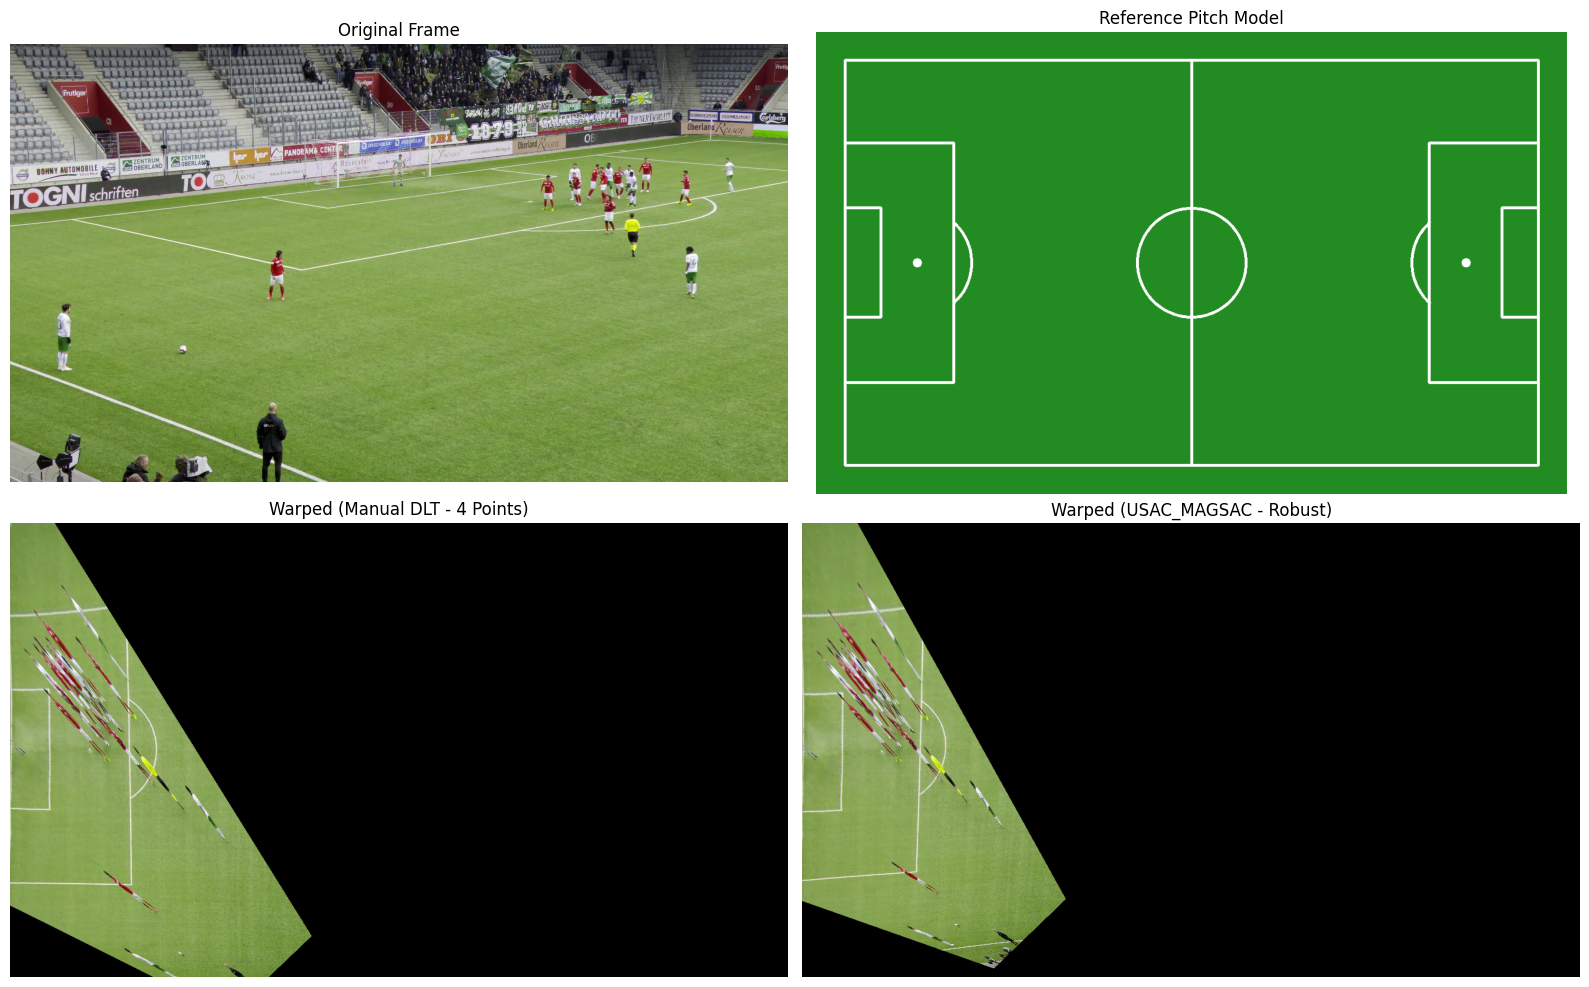

In [7]:
from footballanalytix.visualization import draw_pitch

if H_manual is not None:
    # Tentukan ukuran output (sesuai config pitch)
    # Pitch config: length=12000, width=7000. Kita scale down biar muat di layar.
    scale = 0.1
    out_width = int(config.length * scale)
    out_height = int(config.width * scale)
    
    # Kita perlu scale matriks H agar sesuai dengan resolusi output yang lebih kecil
    S = np.array([
        [scale, 0, 0],
        [0, scale, 0],
        [0, 0, 1]
    ])
    
    # --- 1. Warp dengan Manual DLT ---
    H_vis_manual = S @ H_manual
    warped_manual = cv2.warpPerspective(frame, H_vis_manual, (out_width, out_height))
    
    # --- 2. Warp dengan USAC_MAGSAC (jika ada) ---
    warped_robust = None
    if 'H_cv2_robust' in locals() and H_cv2_robust is not None:
        H_vis_robust = S @ H_cv2_robust
        warped_robust = cv2.warpPerspective(frame, H_vis_robust, (out_width, out_height))

    # --- 3. Gambar Reference Pitch ---
    # draw_pitch akan membuat gambar lapangan sintetis sesuai config
    ref_pitch = draw_pitch(config, scale=scale)

    # --- Plotting ---
    plt.figure(figsize=(16, 10))
    
    # Original Frame
    plt.subplot(2, 2, 1)
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.title("Original Frame")
    plt.axis('off')
    
    # Reference Pitch
    plt.subplot(2, 2, 2)
    # Asumsi draw_pitch mengembalikan BGR (standar OpenCV)
    plt.imshow(cv2.cvtColor(ref_pitch, cv2.COLOR_BGR2RGB))
    plt.title("Reference Pitch Model")
    plt.axis('off')

    # Warped Manual
    plt.subplot(2, 2, 3)
    plt.imshow(cv2.cvtColor(warped_manual, cv2.COLOR_BGR2RGB))
    plt.title("Warped (Manual DLT - 4 Points)")
    plt.axis('off')
    
    # Warped Robust
    if warped_robust is not None:
        plt.subplot(2, 2, 4)
        plt.imshow(cv2.cvtColor(warped_robust, cv2.COLOR_BGR2RGB))
        plt.title("Warped (USAC_MAGSAC - Robust)")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()